In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Cohort check (verify against GEO!):
  GSE98793: case=128 ctrl=64 | raw range [1.131, 13.997] | log2 applied=False | UNSPECIFIED
  GSE63878: case=48 ctrl=48 | raw range [1.918, 13.9] | log2 applied=False | UNSPECIFIED
  GSE32280: case=29 ctrl=8 | raw range [1.46, 13.808] | log2 applied=False | UNSPECIFIED
  GSE39653: case=29 ctrl=24 | raw range [6.445, 14.7] | log2 applied=False | UNSPECIFIED
  GSE54566: case=14 ctrl=14 | raw range [1.0, 41470.0] | log2 applied=True | UNSPECIFIED
  GSE67663: case=112 ctrl=72 | raw range [0.61, 16.256] | log2 applied=False | UNSPECIFIED

[10 hub genes] GSE98793 -> GSE32280 | genes 10/10: ['IGF1R', 'STAT2', 'PML', 'HGF', 'HDAC1', 'JAK2', 'JAK1', 'MDM2', 'ERBB2', 'STAT3']
   OOF AUC (train) 0.694 | Validation AUC 0.427 [0.192, 0.661] | perm p=0.7269 | thr=0.551
[10 hub genes] GSE98793 -> GSE39653 | genes 8/10: ['PML', 'HGF', 'HDAC1', 'JAK2', 'JAK1', 'MDM2', 'ERBB2', 'STAT3']
   OOF AUC (train) 0.619 | Validation AUC 0.665 [0.511, 0.820] | perm p=0.0198 | t

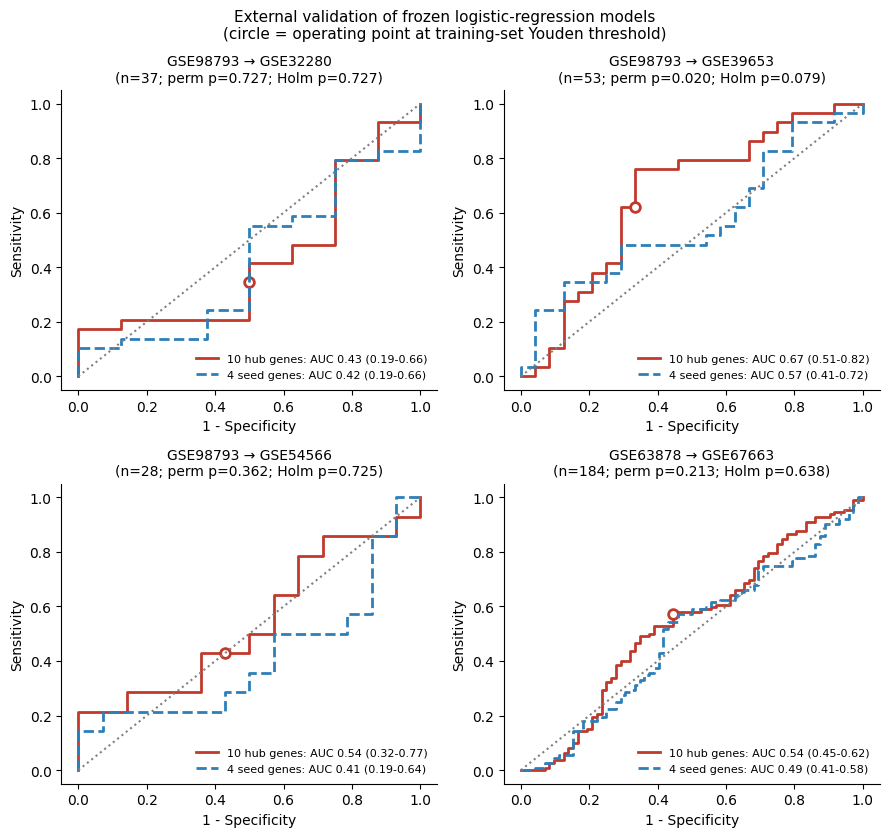

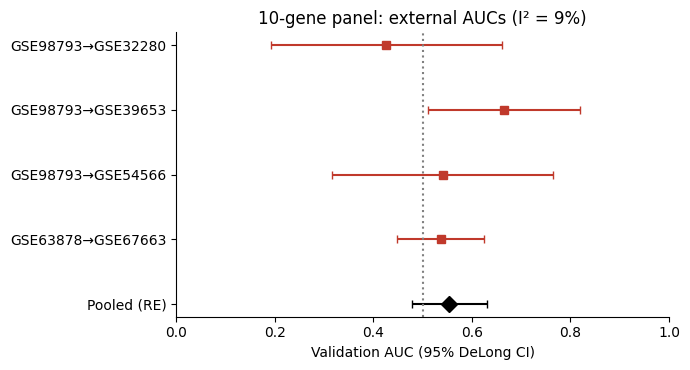


Saved to: /content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/Final_validation/reviewer_final_v2
       Panel    Train     Test  n_genes  Discovery_OOF_AUC  Validation_AUC  CI_DeLong_low  CI_DeLong_high  Sensitivity  Specificity  Balanced_accuracy  p_perm
10 hub genes GSE98793 GSE32280       10              0.694           0.427          0.192           0.661        0.345        0.500              0.422   0.727
10 hub genes GSE98793 GSE39653        8              0.619           0.665          0.511           0.820        0.621        0.667              0.644   0.020
10 hub genes GSE98793 GSE54566       10              0.694           0.541          0.317           0.765        0.429        0.571              0.500   0.362
10 hub genes GSE63878 GSE67663        7              0.606           0.536          0.448           0.625        0.571        0.556              0.563   0.213
4 seed genes GSE98793 GSE

In [ ]:
"""
Frozen-model external validation (Reviewer #2, Concern #5) -- v2 (corrected)

Design (declare in Methods):
  * Model    : L2 logistic regression (class_weight='balanced'), fitted ONCE on the discovery cohort.
  * Freeze   : coefficients + intercept saved before any validation cohort is scored.
  * Scale    : each cohort checked for log2 scale; non-log data -> log2(x+1) (reported).
  * Normal.  : per-cohort gene-wise z-score (own mean/SD; no parameters transferred).
  * Missing  : missing values -> that cohort's gene median; all-missing genes dropped (reported).
  * Probes   : all probe columns of one gene (GENE, GENE.1, ...) averaged after log2.
  * Genes    : genes present in BOTH cohorts; model refitted on that common set in discovery, frozen.
  * Threshold: Youden index on OUT-OF-FOLD discovery predictions (10x repeated 5-fold); fixed beforehand.
  * CI       : DeLong 95% CI (primary); stratified bootstrap CI (secondary).
  * P-value  : one-sided permutation test (5000 label shuffles) + DeLong vs 0.5;
               Holm correction across the 4 primary (10-hub) tests.
  * Pooled   : DerSimonian-Laird random-effects meta-analysis (primary panel).
  * Sensitivity (pre-specified): tissue-matched pairs reported separately; nothing is excluded.
  * AUC < 0.5 is reported as is and NEVER flipped. Labels are set from GEO metadata only.
"""
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

# --------------------------------------------------------------------------------------
# CONFIG  (edit only here)
# --------------------------------------------------------------------------------------
BASE = os.environ.get("BASE", "/content/drive/MyDrive/research/p5-stress_depression/"
                      "p5_stress_depression_journal-20260927T103230Z-1-001/"
                      "p5_stress_depression_journal/Final_validation/")
OUT = os.path.join(BASE, "reviewer_final_v2")
os.makedirs(OUT, exist_ok=True)

NAMES = ["GSE98793", "GSE63878", "GSE32280", "GSE39653", "GSE54566", "GSE67663"]
FILES = {n: os.path.join(BASE, f"{n}_matrix_Transpose_labeled.csv") for n in NAMES}

# Value of `target` that means CASE (MDD/stress). Set from GEO sample metadata, NOT from AUC.
CASE_VALUE = {n: 1 for n in NAMES}

# Expected (n_case, n_control) from GEO; fill these in. The script stops if counts disagree.
EXPECTED_COUNTS = {n: None for n in NAMES}       # e.g. "GSE98793": (128, 64)

# Tissue of each cohort (fill from GEO; used for Table + tissue-matched sensitivity analysis)
TISSUE = {n: "UNSPECIFIED" for n in NAMES}       # e.g. "whole blood", "PBMC", "postmortem brain"

PANELS = {
    "10 hub genes": ["IGF1R", "STAT2", "PML", "HGF", "HDAC1", "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3"],
    "4 seed genes": ["IGF1R", "STAT2", "HGF", "PML"],
}
PRIMARY = "10 hub genes"
PAIRS = [("GSE98793", "GSE32280"), ("GSE98793", "GSE39653"),
         ("GSE98793", "GSE54566"), ("GSE63878", "GSE67663")]   # pre-specified, never changed

SEED, N_PERM, N_BOOT, N_CV_REPEATS = 42, 5000, 2000, 10


# --------------------------------------------------------------------------------------
# HELPERS
# --------------------------------------------------------------------------------------
def gene_cols(gene, cols):
    pat = re.compile(rf"^{re.escape(gene)}(\.\d+)?$", re.IGNORECASE)
    return [c for c in cols if pat.match(str(c).strip())]


_cache = {}


def read_cohort(name):
    """Read once; detect scale on the whole expression matrix (not just panel genes)."""
    if name in _cache:
        return _cache[name]
    df = pd.read_csv(FILES[name])
    if "target" not in df.columns:
        raise ValueError(f"{name}: no 'target' column")
    y = (df["target"].values == CASE_VALUE[name]).astype(int)
    expr = df.drop(columns=["target"]).apply(pd.to_numeric, errors="coerce")
    expr = expr.loc[:, expr.notna().any()]                     # drop non-numeric columns (IDs)
    vmax, vmin = np.nanmax(expr.values), np.nanmin(expr.values)
    logged = False
    if vmax > 50:                                              # raw intensities / counts
        expr = np.log2(expr.clip(lower=0) + 1)
        logged = True
    info = dict(cohort=name, n=len(y), n_case=int(y.sum()), n_ctrl=int((1 - y).sum()),
                raw_min=round(float(vmin), 3), raw_max=round(float(vmax), 3),
                log2_applied=logged, tissue=TISSUE[name])
    _cache[name] = (expr, y, info)
    return _cache[name]


def load(name, genes):
    expr, y, _ = read_cohort(name)
    feats, n_probes = {}, {}
    for g in genes:
        c = gene_cols(g, expr.columns)
        if c:
            v = expr[c].mean(axis=1)
            if v.notna().any():
                feats[g] = v
                n_probes[g] = len(c)
    return pd.DataFrame(feats), y, n_probes


def zscore(X):
    X = X.fillna(X.median())
    sd = X.std(ddof=0).replace(0, 1)
    return (X - X.mean()) / sd


def _midrank(x):
    J = np.argsort(x, kind="mergesort")
    Z = x[J]
    N = len(x)
    T = np.zeros(N)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N)
    T2[J] = T
    return T2


def delong(y, p):
    """AUC and variance (DeLong 1988; Sun & Xu 2014 fast algorithm)."""
    pos, neg = p[y == 1], p[y == 0]
    m, n = len(pos), len(neg)
    tx, ty, tz = _midrank(pos), _midrank(neg), _midrank(np.concatenate([pos, neg]))
    auc = (tz[:m].sum() / m - (m + 1) / 2) / n
    v01 = (tz[:m] - tx) / n
    v10 = 1 - (tz[m:] - ty) / m
    var = np.var(v01, ddof=1) / m + np.var(v10, ddof=1) / n
    return auc, var


def holm(pvals):
    p = np.asarray(pvals, float)
    order = np.argsort(p)
    adj = np.empty_like(p)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (len(p) - rank) * p[idx])
        adj[idx] = min(1.0, running)
    return adj


def oof_probs(Z, y):
    acc = np.zeros(len(y))
    for r in range(N_CV_REPEATS):
        cv = StratifiedKFold(5, shuffle=True, random_state=SEED + r)
        for tr, te in cv.split(Z, y):
            m = LogisticRegression(class_weight="balanced", max_iter=5000)
            m.fit(Z.iloc[tr], y[tr])
            acc[te] += m.predict_proba(Z.iloc[te])[:, 1]
    return acc / N_CV_REPEATS


def youden_threshold(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    return float(thr[np.argmax(tpr - fpr)])


def random_effects(a, se):
    v = se ** 2
    w = 1 / v
    a_fe = np.sum(w * a) / np.sum(w)
    Q = np.sum(w * (a - a_fe) ** 2)
    k = len(a)
    tau2 = max(0.0, (Q - (k - 1)) / (np.sum(w) - np.sum(w ** 2) / np.sum(w))) if k > 1 else 0.0
    w_re = 1 / (v + tau2)
    a_re = np.sum(w_re * a) / np.sum(w_re)
    se_re = np.sqrt(1 / np.sum(w_re))
    I2 = max(0.0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0.0
    return dict(k=k, pooled_AUC=a_re, CI_low=a_re - 1.96 * se_re, CI_high=a_re + 1.96 * se_re,
                tau2=tau2, I2_percent=I2, Q=Q, p_Q=1 - stats.chi2.cdf(Q, k - 1) if k > 1 else np.nan,
                p_vs_0_5=2 * (1 - stats.norm.cdf(abs((a_re - 0.5) / se_re))))


# --------------------------------------------------------------------------------------
# 0. SANITY: labels, scale, tissue  -> Supplementary cohort table
# --------------------------------------------------------------------------------------
cohort_rows = []
print("Cohort check (verify against GEO!):")
for n in NAMES:
    _, y, info = read_cohort(n)
    cohort_rows.append(info)
    print(f"  {n}: case={info['n_case']} ctrl={info['n_ctrl']} | raw range "
          f"[{info['raw_min']}, {info['raw_max']}] | log2 applied={info['log2_applied']} | {info['tissue']}")
    exp = EXPECTED_COUNTS[n]
    if exp is not None and (info["n_case"], info["n_ctrl"]) != tuple(exp):
        raise ValueError(f"{n}: label counts {info['n_case'], info['n_ctrl']} != GEO {exp}. "
                         f"Fix CASE_VALUE/labels from metadata before running.")
pd.DataFrame(cohort_rows).to_csv(f"{OUT}/cohort_characteristics.csv", index=False)
print()

# --------------------------------------------------------------------------------------
# 1. TRAIN -> FREEZE -> TEST
# --------------------------------------------------------------------------------------
rng = np.random.RandomState(SEED)
rows, coef_rows, map_rows, roc_store = [], [], [], {}

for panel_name, genes in PANELS.items():
    for disc, val in PAIRS:
        Xd, yd, npd = load(disc, genes)
        Xv, yv, npv = load(val, genes)
        common = [g for g in genes if g in Xd.columns and g in Xv.columns]
        for g in genes:
            map_rows.append(dict(Panel=panel_name, Train=disc, Test=val, Gene=g,
                                 probes_train=npd.get(g, 0), probes_test=npv.get(g, 0),
                                 used=g in common))
        if not common:
            print(f"[{panel_name}] {disc}->{val}: no common genes, skipped")
            continue

        Zd, Zv = zscore(Xd[common]), zscore(Xv[common])

        # (a) discovery OOF performance + threshold (fixed before validation)
        p_oof = oof_probs(Zd, yd)
        auc_disc = roc_auc_score(yd, p_oof)
        thr = youden_threshold(yd, p_oof)

        # (b) final discovery model -> FREEZE
        model = LogisticRegression(class_weight="balanced", max_iter=5000).fit(Zd, yd)
        coef_rows.append({"Panel": panel_name, "Train": disc, "Test": val,
                          "Intercept": float(model.intercept_[0]), "Threshold_Youden_train": thr,
                          **dict(zip(common, model.coef_[0]))})

        # (c) validation: frozen model applied unchanged
        prob = model.predict_proba(Zv[common])[:, 1]
        auc_val, var = delong(yv, prob)
        se = np.sqrt(var)
        ci_lo, ci_hi = max(0, auc_val - 1.96 * se), min(1, auc_val + 1.96 * se)
        p_delong = 2 * (1 - stats.norm.cdf(abs((auc_val - 0.5) / se)))

        idx0, idx1 = np.where(yv == 0)[0], np.where(yv == 1)[0]
        boots = [roc_auc_score(yv[i], prob[i]) for i in
                 (np.concatenate([rng.choice(idx0, len(idx0)), rng.choice(idx1, len(idx1))])
                  for _ in range(N_BOOT))]
        perm = np.array([roc_auc_score(rng.permutation(yv), prob) for _ in range(N_PERM)])
        p_perm = (np.sum(perm >= auc_val) + 1) / (N_PERM + 1)

        pred = (prob >= thr).astype(int)
        tp = int(((pred == 1) & (yv == 1)).sum()); fn = int(((pred == 0) & (yv == 1)).sum())
        tn = int(((pred == 0) & (yv == 0)).sum()); fp = int(((pred == 1) & (yv == 0)).sum())
        sens, spec = tp / (tp + fn), tn / (tn + fp)
        bal_acc = (sens + spec) / 2

        tissue_matched = TISSUE[disc] == TISSUE[val] and TISSUE[disc] != "UNSPECIFIED"
        print(f"[{panel_name}] {disc} -> {val} | genes {len(common)}/{len(genes)}: {common}")
        print(f"   OOF AUC (train) {auc_disc:.3f} | Validation AUC {auc_val:.3f} "
              f"[{ci_lo:.3f}, {ci_hi:.3f}] | perm p={p_perm:.4f} | thr={thr:.3f}")

        fpr_, tpr_, _ = roc_curve(yv, prob)
        roc_store[(panel_name, disc, val)] = dict(fpr=fpr_, tpr=tpr_, auc=auc_val, ci=(ci_lo, ci_hi),
                                                  op=(fp / (fp + tn), sens))
        rows.append({
            "Panel": panel_name, "Train": disc, "Test": val,
            "Tissue_train": TISSUE[disc], "Tissue_test": TISSUE[val], "Tissue_matched": tissue_matched,
            "n_test": len(yv), "n_case": int(yv.sum()), "n_ctrl": int((1 - yv).sum()),
            "n_genes": len(common), "genes_used": ", ".join(common),
            "Discovery_OOF_AUC": auc_disc, "Validation_AUC": auc_val, "AUC_SE": se,
            "CI_DeLong_low": ci_lo, "CI_DeLong_high": ci_hi,
            "CI_boot_low": np.percentile(boots, 2.5), "CI_boot_high": np.percentile(boots, 97.5),
            "Threshold_train": thr, "TP": tp, "FN": fn, "TN": tn, "FP": fp,
            "Sensitivity": sens, "Specificity": spec, "Balanced_accuracy": bal_acc,
            "p_perm": p_perm, "p_DeLong_vs_0.5": p_delong,
        })

res = pd.DataFrame(rows)
mask = res["Panel"] == PRIMARY
res.loc[mask, "p_perm_Holm"] = holm(res.loc[mask, "p_perm"].values)

pd.DataFrame(coef_rows).round(4).to_csv(f"{OUT}/frozen_coefficients.csv", index=False)
pd.DataFrame(map_rows).to_csv(f"{OUT}/gene_probe_mapping.csv", index=False)
res.round(4).to_csv(f"{OUT}/frozen_validation_results.csv", index=False)

# --------------------------------------------------------------------------------------
# 2. META-ANALYSIS (primary panel: all pairs; sensitivity: tissue-matched only)
# --------------------------------------------------------------------------------------
prim = res[mask].copy()
meta_rows = [dict(Analysis="All pre-specified pairs",
                  **random_effects(prim["Validation_AUC"].values, prim["AUC_SE"].values))]
tm = prim[prim["Tissue_matched"]]
if len(tm) >= 2:
    meta_rows.append(dict(Analysis="Tissue-matched pairs (sensitivity)",
                          **random_effects(tm["Validation_AUC"].values, tm["AUC_SE"].values)))
meta_df = pd.DataFrame(meta_rows)
meta_df.round(4).to_csv(f"{OUT}/meta_analysis.csv", index=False)
meta = meta_rows[0]
print(f"\nPooled AUC (RE, all pairs): {meta['pooled_AUC']:.3f} "
      f"[{meta['CI_low']:.3f}, {meta['CI_high']:.3f}] | I2={meta['I2_percent']:.1f}% | "
      f"p vs 0.5 = {meta['p_vs_0_5']:.3f}")

# --------------------------------------------------------------------------------------
# 3. FIGURES
# --------------------------------------------------------------------------------------
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

fig, axes = plt.subplots(2, 2, figsize=(9, 8.5))
for ax, (disc, val) in zip(axes.ravel(), PAIRS):
    for panel_name, ls, col in [(PRIMARY, "-", "#c0392b"), ("4 seed genes", "--", "#2c7fb8")]:
        d = roc_store.get((panel_name, disc, val))
        if d is None:
            continue
        ax.plot(d["fpr"], d["tpr"], ls, color=col, lw=2,
                label=f"{panel_name}: AUC {d['auc']:.2f} ({d['ci'][0]:.2f}-{d['ci'][1]:.2f})")
        if panel_name == PRIMARY:
            ax.plot(*d["op"], "o", color=col, ms=7, mfc="white", mew=2)
    ax.plot([0, 1], [0, 1], ":", color="grey")
    pr = res[(res.Panel == PRIMARY) & (res.Train == disc) & (res.Test == val)]
    if len(pr):
        pr = pr.iloc[0]
        ax.set_title(f"{disc} → {val}\n(n={pr.n_test}; perm p={pr.p_perm:.3f}; "
                     f"Holm p={pr.p_perm_Holm:.3f})", fontsize=10)
    ax.set_xlabel("1 - Specificity"); ax.set_ylabel("Sensitivity")
    ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.suptitle("External validation of frozen logistic-regression models\n"
             "(circle = operating point at training-set Youden threshold)", fontsize=11)
fig.tight_layout()
fig.savefig(f"{OUT}/Fig_ROC_frozen_validation.png", dpi=300)
fig.savefig(f"{OUT}/Fig_ROC_frozen_validation.pdf")

fig2, ax = plt.subplots(figsize=(7, 3.8))
ylab = [f"{r.Train}→{r.Test}" for _, r in prim.iterrows()] + ["Pooled (RE)"]
ypos = np.arange(len(ylab))[::-1]
for y_, (_, r) in zip(ypos[:-1], prim.iterrows()):
    ax.errorbar(r.Validation_AUC, y_, xerr=[[r.Validation_AUC - r.CI_DeLong_low],
                [r.CI_DeLong_high - r.Validation_AUC]], fmt="s", color="#c0392b", capsize=3)
ax.errorbar(meta["pooled_AUC"], ypos[-1],
            xerr=[[meta["pooled_AUC"] - meta["CI_low"]], [meta["CI_high"] - meta["pooled_AUC"]]],
            fmt="D", color="black", capsize=3, ms=8)
ax.axvline(0.5, ls=":", color="grey")
ax.set_yticks(ypos); ax.set_yticklabels(ylab)
ax.set_xlabel("Validation AUC (95% DeLong CI)"); ax.set_xlim(0, 1)
ax.set_title(f"10-gene panel: external AUCs (I² = {meta['I2_percent']:.0f}%)")
fig2.tight_layout()
fig2.savefig(f"{OUT}/Fig_forest_AUC.png", dpi=300)
fig2.savefig(f"{OUT}/Fig_forest_AUC.pdf")

if os.environ.get("SHOW", "1") == "1":
    plt.show()

print(f"\nSaved to: {OUT}")
print(res[["Panel", "Train", "Test", "n_genes", "Discovery_OOF_AUC", "Validation_AUC",
           "CI_DeLong_low", "CI_DeLong_high", "Sensitivity", "Specificity",
           "Balanced_accuracy", "p_perm"]].round(3).to_string(index=False))

#Final_Code

In [ ]:
!pip -q install GEOparse
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =====================================================================================
# FINAL EXTERNAL VALIDATION  (Reviewer #2, Concerns #5 and #6)  -- run once in Colab
#   * Sample groups taken from GEO; bipolar and SSD samples excluded from validation cohorts
#   * Cohorts whose matrix does not match the GEO series are excluded and reported
#   * Primary: frozen L2 logistic regression trained in the discovery cohort only
#   * Also: 4-seed-gene panel, single 10-gene model, leave-one-cohort-out, internal nested CV
#   * Output: Final_validation/Final_Validation_Last/{tables, figures, logs}
# =====================================================================================
import os, re, json, warnings
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
warnings.filterwarnings("ignore")

# ------------------------------------------------------------------ CONFIG
BASE = os.environ.get("BASE", "/content/drive/MyDrive/research/p5-stress_depression/p5_stress_depression_journal-20260927T103230Z-1-001/p5_stress_depression_journal/Final_validation/")
OUT = os.path.join(BASE, "Final_Validation_Last")
TAB, FIG, LOG = (os.path.join(OUT, d) for d in ("tables", "figures", "logs"))
GEO_CACHE = os.environ.get("GEO_CACHE", "/content/geo_cache")
for d in (TAB, FIG, LOG, GEO_CACHE): os.makedirs(d, exist_ok=True)
FILE = lambda g: os.path.join(BASE, f"{g}_matrix_Transpose_labeled.csv")

DISCOVERY  = {"GSE98793": "MDD", "GSE63878": "PTSD"}
VALIDATION = {"GSE32280": "MDD", "GSE39653": "MDD", "GSE54566": "MDD", "GSE67663": "Comorbid PTSD+MDD"}
TRAIN_FOR  = {"GSE32280": "GSE98793", "GSE39653": "GSE98793", "GSE54566": "GSE98793", "GSE67663": "GSE63878"}
GROUP_OF   = {"GSE98793": "MDD", "GSE32280": "MDD", "GSE39653": "MDD", "GSE54566": "MDD",
              "GSE63878": "PTSD-related", "GSE67663": "PTSD-related"}
CASE_VALUE = 1
PANELS = {"10 hub genes": ["IGF1R", "STAT2", "PML", "HGF", "HDAC1", "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3"],
          "4 seed genes": ["IGF1R", "STAT2", "HGF", "PML"]}
PRIMARY = "10 hub genes"
SEED, N_PERM, N_BOOT, N_CV = 42, 5000, 2000, 10
C_GRID = [0.01, 0.1, 1.0, 10.0]
rng = np.random.RandomState(SEED)
LOGTXT = []
def say(*a):
    s = " ".join(str(x) for x in a); print(s); LOGTXT.append(s)

# ------------------------------------------------------------------ GEO METADATA
RX = {"bipolar": r"\bbipolar\b|\bbd\b", "SSD": r"subsyndromal|\bssd\b",
      "control": r"\bcontrols?\b|\bhealthy\b|\bnormal\b|\bhc\b"}
def get_geo_meta(gse):
    """Return dict(platform, tissue, n, groups: list in GSM order)."""
    import GEOparse
    try:
        g = GEOparse.get_GEO(geo=gse, destdir=GEO_CACHE, how="brief", silent=True)
    except Exception:
        g = GEOparse.get_GEO(geo=gse, destdir=GEO_CACHE, silent=True)
    ph = g.phenotype_data
    cols = [c for c in ph.columns if c == "title" or c.startswith("characteristics_ch1") or c == "source_name_ch1"]
    text = ph[cols].astype(str).apply(lambda r: " | ".join(r.values).lower(), axis=1)
    groups = []
    for t in text:
        lab = "other"
        for k in ("bipolar", "SSD", "control"):
            if re.search(RX[k], t): lab = k; break
        groups.append(lab)
    groups = pd.Series(groups)
    for k in ("bipolar", "SSD", "control"):           # a label matching every sample is not informative
        if (groups == k).all(): groups[:] = "other"
    plat = ",".join(g.metadata.get("platform_id", ["NA"]))
    tissue = "; ".join(sorted(set(ph.get("source_name_ch1", pd.Series(["NA"])).astype(str))))[:150]
    return dict(platform=plat, tissue=tissue, n=len(ph), groups=list(groups), gsm=list(ph.index))

# ------------------------------------------------------------------ LOAD COHORTS
def gene_cols(gene, cols):
    pat = re.compile(rf"^{re.escape(gene)}(\.\d+)?$", re.IGNORECASE)
    return [c for c in cols if pat.match(str(c).strip())]

ALL_GENES = sorted(set(sum(PANELS.values(), [])))
COH, INFO = {}, []
for gse in list(DISCOVERY) + list(VALIDATION):
    role = "Discovery" if gse in DISCOVERY else "Validation"
    df = pd.read_csv(FILE(gse))
    y_all = (df["target"].values == CASE_VALUE).astype(int)
    rec = dict(GEO=gse, Role=role, Phenotype=DISCOVERY.get(gse, VALIDATION.get(gse)), Matrix_rows=len(df))
    try:
        meta = get_geo_meta(gse)
        rec.update(Platform=meta["platform"], Tissue_GEO=meta["tissue"], GEO_samples=meta["n"])
    except Exception as e:
        meta = None; rec.update(Platform="NA", Tissue_GEO="NA", GEO_samples=np.nan)
        say(f"  {gse}: GEO metadata not available ({e})")
    keep = np.ones(len(df), bool); status = "used"
    if role == "Validation" and meta is not None:
        if meta["n"] != len(df):
            status = f"excluded: matrix rows ({len(df)}) do not match GEO series ({meta['n']})"
        else:
            grp = pd.Series(meta["groups"])
            excl = grp.isin(["bipolar", "SSD"]).values
            bad_ctrl = ((grp == "control").values & (y_all == 1)).any()
            bad_excl = (excl & (y_all == 0)).any()
            if bad_ctrl or bad_excl:
                status = "excluded: GEO groups disagree with matrix labels (sample order not verified)"
            else:
                keep = ~excl
                rec.update(Excluded_bipolar=int((grp == "bipolar").sum()), Excluded_SSD=int((grp == "SSD").sum()))
    rec["Status"] = status
    if status != "used":
        say(f"  {gse}: {status}"); INFO.append(rec); continue
    df = df.loc[keep].reset_index(drop=True); y = y_all[keep]
    expr = df.drop(columns=["target"]).apply(pd.to_numeric, errors="coerce")
    expr = expr.loc[:, expr.notna().any()]
    logged = np.nanmax(expr.values) > 50
    if logged: expr = np.log2(expr.clip(lower=0) + 1)
    feats, nprobe = {}, {}
    for gname in ALL_GENES:
        c = gene_cols(gname, expr.columns)
        if c and expr[c].notna().any().any():
            feats[gname] = expr[c].mean(axis=1); nprobe[gname] = len(c)
    X = pd.DataFrame(feats); X = X.fillna(X.median())
    COH[gse] = dict(X=X, y=y)
    rec.update(n_used=len(y), n_case=int(y.sum()), n_control=int((1 - y).sum()), log2_applied=bool(logged),
               Hub_genes_available=sum(g in X for g in PANELS[PRIMARY]),
               Hub_genes_missing=", ".join(g for g in PANELS[PRIMARY] if g not in X) or "none",
               **{f"probes_{g}": nprobe.get(g, 0) for g in PANELS[PRIMARY]})
    INFO.append(rec)
    say(f"  {gse} [{role}]: used {len(y)} (case {int(y.sum())} / control {int((1-y).sum())}); "
        f"excluded bipolar {rec.get('Excluded_bipolar', 0)}, SSD {rec.get('Excluded_SSD', 0)}; log2 {logged}")
pd.DataFrame(INFO).to_csv(os.path.join(TAB, "S9_cohort_characteristics.csv"), index=False, encoding="utf-8-sig")
VAL_USED = [g for g in VALIDATION if g in COH]

# ------------------------------------------------------------------ STATISTICS
def zs(X): return (X - X.mean()) / X.std(ddof=0).replace(0, 1)
def lr(C=1.0): return LogisticRegression(C=C, class_weight="balanced", max_iter=5000)
def _midrank(x):
    J = np.argsort(x, kind="mergesort"); Z = x[J]; N = len(x); T = np.zeros(N); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]: j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1; i = j
    T2 = np.empty(N); T2[J] = T; return T2
def delong(y, p):
    pos, neg = p[y == 1], p[y == 0]; m, n = len(pos), len(neg)
    tx, ty, tz = _midrank(pos), _midrank(neg), _midrank(np.concatenate([pos, neg]))
    auc = (tz[:m].sum() / m - (m + 1) / 2) / n
    var = np.var((tz[:m] - tx) / n, ddof=1) / m + np.var(1 - (tz[m:] - ty) / m, ddof=1) / n
    return auc, var
def holm(p):
    p = np.asarray(p, float); o = np.argsort(p); adj = np.empty_like(p); run = 0.0
    for k, i in enumerate(o): run = max(run, (len(p) - k) * p[i]); adj[i] = min(1.0, run)
    return adj
def oof(X, y):
    acc = np.zeros(len(y))
    for r in range(N_CV):
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED + r).split(X, y):
            acc[te] += lr().fit(X.iloc[tr], y[tr]).predict_proba(X.iloc[te])[:, 1]
    return acc / N_CV
def youden(y, p):
    f, t, th = roc_curve(y, p); return float(th[np.argmax(t - f)])
def evaluate(y, prob, thr, perm=True):
    auc, var = delong(y, prob); se = np.sqrt(var)
    i0, i1 = np.where(y == 0)[0], np.where(y == 1)[0]
    boots = [roc_auc_score(y[i], prob[i]) for i in (np.concatenate([rng.choice(i0, len(i0)), rng.choice(i1, len(i1))]) for _ in range(N_BOOT))]
    out = dict(AUC=auc, SE=se, CI_low=max(0, auc - 1.96 * se), CI_high=min(1, auc + 1.96 * se),
               Boot_CI_low=np.percentile(boots, 2.5), Boot_CI_high=np.percentile(boots, 97.5),
               p_DeLong_vs_0_5=2 * (1 - stats.norm.cdf(abs((auc - 0.5) / se))))
    if perm:
        null = np.array([roc_auc_score(rng.permutation(y), prob) for _ in range(N_PERM)])
        out["p_perm"] = (np.sum(null >= auc) + 1) / (N_PERM + 1)
    if thr is not None:
        pr = prob >= thr
        tp, fn = int((pr & (y == 1)).sum()), int((~pr & (y == 1)).sum())
        tn, fp = int((~pr & (y == 0)).sum()), int((pr & (y == 0)).sum())
        se_, sp_ = tp / (tp + fn), tn / (tn + fp)
        out.update(Threshold=thr, TP=tp, FN=fn, TN=tn, FP=fp, Sensitivity=se_, Specificity=sp_,
                   Accuracy=(tp + tn) / len(y), Balanced_accuracy=(se_ + sp_) / 2)
    return out
def random_effects(a, s):
    v = s ** 2; w = 1 / v; k = len(a); afe = (w * a).sum() / w.sum(); Q = (w * (a - afe) ** 2).sum()
    tau2 = max(0, (Q - (k - 1)) / (w.sum() - (w ** 2).sum() / w.sum())) if k > 1 else 0.0
    wr = 1 / (v + tau2); are = (wr * a).sum() / wr.sum(); se = np.sqrt(1 / wr.sum())
    return dict(k=k, Pooled_AUC=are, CI_low=are - 1.96 * se, CI_high=are + 1.96 * se, tau2=tau2,
                I2_percent=max(0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0.0,
                p_vs_0_5=2 * (1 - stats.norm.cdf(abs((are - 0.5) / se))))

# ------------------------------------------------------------------ PRIMARY + SEED (frozen, shared genes)
rows, coefs, rocs = [], [], {}
for panel, genes in PANELS.items():
    for val in VAL_USED:
        disc = TRAIN_FOR[val]
        common = [g for g in genes if g in COH[disc]["X"] and g in COH[val]["X"]]
        Xd, yd = zs(COH[disc]["X"][common]), COH[disc]["y"]
        Xv, yv = zs(COH[val]["X"][common]), COH[val]["y"]
        p_oof = oof(Xd, yd); thr = youden(yd, p_oof)
        m = lr().fit(Xd, yd)
        coefs.append({"Panel": panel, "Discovery": disc, "Validation": val, "Intercept": m.intercept_[0],
                      "Threshold_Youden_discovery": thr, **dict(zip(common, m.coef_[0]))})
        prob = m.predict_proba(Xv)[:, 1]
        r = dict(Analysis="Primary frozen" if panel == PRIMARY else "Seed-gene panel (frozen)", Panel=panel,
                 Phenotype=VALIDATION[val], Discovery=disc, Validation=val, n=len(yv), n_case=int(yv.sum()),
                 n_control=int((1 - yv).sum()), Genes_used=len(common), Genes=", ".join(common),
                 Discovery_OOF_AUC=roc_auc_score(yd, p_oof), **evaluate(yv, prob, thr))
        rows.append(r); f, t, _ = roc_curve(yv, prob); rocs[(panel, val)] = (f, t, r)
        say(f"[{panel}] {disc} -> {val} ({len(common)} genes): AUC {r['AUC']:.3f} [{r['CI_low']:.3f}, {r['CI_high']:.3f}] perm p {r['p_perm']:.4f}")

# ------------------------------------------------------------------ SENSITIVITY: single 10-gene model
G10 = PANELS[PRIMARY]
for disc in set(TRAIN_FOR[v] for v in VAL_USED):
    Xd, yd = zs(COH[disc]["X"]).reindex(columns=G10).fillna(0.0), COH[disc]["y"]
    thr = youden(yd, oof(Xd, yd)); m = lr().fit(Xd, yd)
    coefs.append({"Panel": "10 hub genes (single model)", "Discovery": disc, "Validation": "all",
                  "Intercept": m.intercept_[0], "Threshold_Youden_discovery": thr, **dict(zip(G10, m.coef_[0]))})
    for val in [v for v in VAL_USED if TRAIN_FOR[v] == disc]:
        Xv, yv = zs(COH[val]["X"]).reindex(columns=G10).fillna(0.0), COH[val]["y"]
        r = dict(Analysis="Sensitivity: single 10-gene model", Panel=PRIMARY, Phenotype=VALIDATION[val],
                 Discovery=disc, Validation=val, n=len(yv), Genes_used=sum(g in COH[val]["X"] for g in G10),
                 **evaluate(yv, m.predict_proba(Xv)[:, 1], thr))
        rows.append(r)

# ------------------------------------------------------------------ SECONDARY: leave-one-cohort-out
for grp in sorted(set(GROUP_OF[g] for g in COH)):
    members = [g for g in COH if GROUP_OF[g] == grp]
    if len(members) < 2: continue
    for test in members:
        train = [g for g in members if g != test]
        genes = [g for g in G10 if all(g in COH[c]["X"] for c in members)]
        Xtr = pd.concat([zs(COH[c]["X"][genes]) for c in train], ignore_index=True)
        ytr = np.concatenate([COH[c]["y"] for c in train])
        grpv = np.concatenate([[c] * len(COH[c]["y"]) for c in train])
        if len(train) >= 2:
            p_in = np.zeros(len(ytr))
            for c in train:
                te = grpv == c; p_in[te] = lr().fit(Xtr[~te], ytr[~te]).predict_proba(Xtr[te])[:, 1]
        else:
            p_in = oof(Xtr, ytr)
        m = lr().fit(Xtr, ytr); Xte, yte = zs(COH[test]["X"][genes]), COH[test]["y"]
        rows.append(dict(Analysis="Secondary: leave-one-cohort-out", Panel=PRIMARY, Phenotype=grp,
                         Discovery="+".join(train), Validation=test, n=len(yte), Genes_used=len(genes),
                         **evaluate(yte, m.predict_proba(Xte)[:, 1], youden(ytr, p_in))))

# ------------------------------------------------------------------ INTERNAL: nested CV (not external)
for gse in COH:
    X, y = COH[gse]["X"][[g for g in G10 if g in COH[gse]["X"]]].values, COH[gse]["y"]
    acc = np.zeros(len(y))
    for r in range(N_CV):
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED + r).split(X, y):
            inner = StratifiedKFold(5, shuffle=True, random_state=SEED + 100 + r); best, bc = -1, 1.0
            for C in C_GRID:
                s = np.mean([roc_auc_score(y[tr][b], make_pipeline(StandardScaler(), lr(C)).fit(X[tr][a], y[tr][a]).predict_proba(X[tr][b])[:, 1])
                             for a, b in inner.split(X[tr], y[tr])])
                if s > best: best, bc = s, C
            acc[te] += make_pipeline(StandardScaler(), lr(bc)).fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
    rows.append(dict(Analysis="Internal: within-cohort nested CV (not external)", Panel=PRIMARY,
                     Phenotype=DISCOVERY.get(gse, VALIDATION.get(gse)), Discovery=gse, Validation=gse,
                     n=len(y), Genes_used=X.shape[1], **evaluate(y, acc / N_CV, None, perm=False)))

res = pd.DataFrame(rows)
for a in res.Analysis.unique():
    mk = (res.Analysis == a) & res.p_perm.notna()
    if mk.any(): res.loc[mk, "p_perm_Holm"] = holm(res.loc[mk, "p_perm"].values)

# ------------------------------------------------------------------ META-ANALYSIS
meta = []
for a in ["Primary frozen", "Seed-gene panel (frozen)", "Sensitivity: single 10-gene model"]:
    d = res[res.Analysis == a]
    if len(d): meta.append(dict(Analysis=a, Pool="All validation cohorts", **random_effects(d.AUC.values, d.SE.values)))
    dm = d[d.Phenotype == "MDD"]
    if len(dm) >= 2: meta.append(dict(Analysis=a, Pool="MDD cohorts", **random_effects(dm.AUC.values, dm.SE.values)))
meta = pd.DataFrame(meta)

# ------------------------------------------------------------------ TABLES
res.round(4).to_csv(os.path.join(TAB, "S8_all_validation_analyses.csv"), index=False, encoding="utf-8-sig")
meta.round(4).to_csv(os.path.join(TAB, "S8b_meta_analysis.csv"), index=False, encoding="utf-8-sig")
cf = pd.DataFrame(coefs).round(4); cf.to_csv(os.path.join(TAB, "S10_frozen_model_coefficients.csv"), index=False, encoding="utf-8-sig")
p = res[res.Analysis == "Primary frozen"]
t5 = pd.DataFrame({"Phenotype": p.Phenotype, "Discovery \u2192 Validation": p.Discovery + " \u2192 " + p.Validation,
                   "n (case/control)": [f"{int(a)} ({int(b)}/{int(c)})" for a, b, c in zip(p.n, p.n_case, p.n_control)],
                   "Genes": [f"{int(g)}/10" for g in p.Genes_used],
                   "AUC (95% CI)": [f"{a:.2f} ({l:.2f}\u2013{h:.2f})" for a, l, h in zip(p.AUC, p.CI_low, p.CI_high)],
                   "Sensitivity": p.Sensitivity.round(2), "Specificity": p.Specificity.round(2),
                   "Balanced accuracy": p.Balanced_accuracy.round(2), "Holm p": p.p_perm_Holm.round(3)})
mp = meta[(meta.Analysis == "Primary frozen") & (meta.Pool == "All validation cohorts")]
if len(mp):
    mp = mp.iloc[0]
    t5.loc[len(t5)] = ["Pooled (random effects)", "", "", "", f"{mp.Pooled_AUC:.2f} ({mp.CI_low:.2f}\u2013{mp.CI_high:.2f}); I\u00b2 = {mp.I2_percent:.0f}%", "", "", "", ""]
t5.to_csv(os.path.join(TAB, "Table5_external_validation.csv"), index=False, encoding="utf-8-sig")
with pd.ExcelWriter(os.path.join(TAB, "Validation_all_tables.xlsx")) as xw:
    t5.to_excel(xw, sheet_name="Table5", index=False); res.round(4).to_excel(xw, sheet_name="S8_all_analyses", index=False)
    meta.round(4).to_excel(xw, sheet_name="S8b_meta", index=False); pd.DataFrame(INFO).to_excel(xw, sheet_name="S9_cohorts", index=False)
    cf.to_excel(xw, sheet_name="S10_coefficients", index=False)

# ------------------------------------------------------------------ FIGURES
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})
def savefig(fig, name):
    for ext in ("png", "tiff"): fig.savefig(os.path.join(FIG, f"{name}.{ext}"), dpi=600, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if ext == "tiff" else {}))
    fig.savefig(os.path.join(FIG, f"{name}.pdf"), bbox_inches="tight")
k = len(VAL_USED); nc = 2 if k > 1 else 1; nr = int(np.ceil(k / nc))
fig, axes = plt.subplots(nr, nc, figsize=(3.7 * nc, 3.6 * nr), squeeze=False)
for ax, val in zip(axes.ravel(), VAL_USED):
    for panel, ls, col in [(PRIMARY, "-", "#C0392B"), ("4 seed genes", "--", "#2E86C1")]:
        f, t, r = rocs[(panel, val)]
        ax.plot(f, t, ls, color=col, lw=2, label=f"{panel}: {r['AUC']:.2f} ({r['CI_low']:.2f}\u2013{r['CI_high']:.2f})")
        if panel == PRIMARY: ax.plot(1 - r["Specificity"], r["Sensitivity"], "o", ms=7, mfc="white", mec=col, mew=2)
    ax.plot([0, 1], [0, 1], ":", color="grey"); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    rp = res[(res.Analysis == "Primary frozen") & (res.Validation == val)].iloc[0]
    ax.set_title(f"{TRAIN_FOR[val]} \u2192 {val}\n{VALIDATION[val]}; n = {rp.n}; Holm p = {rp.p_perm_Holm:.3f}", fontsize=9)
    ax.set_xlabel("1 \u2212 Specificity"); ax.set_ylabel("Sensitivity"); ax.legend(loc="lower right", fontsize=7, frameon=False)
for ax in axes.ravel()[k:]: ax.axis("off")
fig.suptitle("External validation of frozen logistic-regression models", fontweight="bold")
fig.tight_layout(); savefig(fig, "Fig7_ROC_external_validation"); plt.close(fig)

fp = res[res.Analysis == "Primary frozen"].reset_index(drop=True)
mrows = meta[meta.Analysis == "Primary frozen"].reset_index(drop=True)
labels = [f"{r.Validation} ({r.Phenotype})" for _, r in fp.iterrows()] + [f"Pooled: {m.Pool}" for _, m in mrows.iterrows()]
fig, ax = plt.subplots(figsize=(6.5, 0.45 * len(labels) + 1.2)); ypos = np.arange(len(labels))[::-1]
for yy, (_, r) in zip(ypos, fp.iterrows()):
    ax.errorbar(r.AUC, yy, xerr=[[r.AUC - r.CI_low], [r.CI_high - r.AUC]], fmt="s", color="#C0392B", capsize=3, ms=6)
for yy, (_, m) in zip(ypos[len(fp):], mrows.iterrows()):
    ax.errorbar(m.Pooled_AUC, yy, xerr=[[m.Pooled_AUC - m.CI_low], [m.CI_high - m.Pooled_AUC]], fmt="D", color="black", capsize=3, ms=7)
ax.axvline(0.5, ls=":", color="grey"); ax.set_xlim(0, 1); ax.set_yticks(ypos); ax.set_yticklabels(labels)
ax.set_xlabel("AUC (95% DeLong CI)"); ax.set_title("10-hub-gene frozen model: external AUCs", fontweight="bold")
fig.tight_layout(); savefig(fig, "FigS_forest_external_AUC"); plt.close(fig)

an = ["Primary frozen", "Sensitivity: single 10-gene model", "Secondary: leave-one-cohort-out", "Internal: within-cohort nested CV (not external)"]
cols = ["#C0392B", "#2E86C1", "#27AE60", "#7F8C8D"]; sub = res[res.Analysis.isin(an)].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7, 0.32 * len(sub) + 1.5)); y0 = 0; ticks, labs = [], []
for a, c in zip(an, cols):
    for _, r in sub[sub.Analysis == a].iterrows():
        ax.errorbar(r.AUC, -y0, xerr=[[r.AUC - r.CI_low], [r.CI_high - r.AUC]], fmt="s", color=c, capsize=2, ms=5)
        ticks.append(-y0); labs.append(f"{a.split(':')[0]}: {r.Validation}"); y0 += 1
    y0 += 0.6
ax.axvline(0.5, ls=":", color="grey"); ax.set_xlim(0, 1); ax.set_yticks(ticks); ax.set_yticklabels(labs, fontsize=7)
ax.set_xlabel("AUC (95% DeLong CI)"); ax.set_title("All pre-specified validation analyses", fontweight="bold")
fig.tight_layout(); savefig(fig, "FigS_all_analyses_forest"); plt.close(fig)

# ------------------------------------------------------------------ SUMMARY
json.dump(dict(N_PERM=N_PERM, N_BOOT=N_BOOT, N_CV=N_CV, SEED=SEED, panels=PANELS, train_for=TRAIN_FOR,
               validation_used=VAL_USED, excluded=[r for r in INFO if r["Status"] != "used"]),
          open(os.path.join(LOG, "run_settings.json"), "w"), indent=2, default=str)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 20)
say("\nTABLE 5\n" + t5.to_string(index=False))
say("\nMETA-ANALYSIS\n" + meta.round(3).to_string(index=False))
say("\nALL ANALYSES\n" + res[["Analysis", "Discovery", "Validation", "n", "Genes_used", "AUC", "CI_low", "CI_high", "p_perm", "p_perm_Holm"]].round(3).to_string(index=False))
say("\nCOHORTS\n" + pd.DataFrame(INFO)[["GEO", "Role", "Status", "Matrix_rows", "GEO_samples"]].to_string(index=False))
open(os.path.join(LOG, "run_log.txt"), "w").write("\n".join(LOGTXT))
say(f"\nSaved to {OUT}: tables {sorted(os.listdir(TAB))}; figures {len(os.listdir(FIG))} files")

  GSE98793 [Discovery]: used 192 (case 128 / control 64); excluded bipolar 0, SSD 0; log2 False
  GSE63878 [Discovery]: used 96 (case 48 / control 48); excluded bipolar 0, SSD 0; log2 False
  GSE32280 [Validation]: used 24 (case 16 / control 8); excluded bipolar 0, SSD 13; log2 False
  GSE39653 [Validation]: used 45 (case 21 / control 24); excluded bipolar 8, SSD 0; log2 False
  GSE54566 [Validation]: used 28 (case 14 / control 14); excluded bipolar 0, SSD 0; log2 True
  GSE67663 [Validation]: used 184 (case 112 / control 72); excluded bipolar 0, SSD 0; log2 False
[10 hub genes] GSE98793 -> GSE32280 (10 genes): AUC 0.523 [0.258, 0.788] perm p 0.4479
[10 hub genes] GSE98793 -> GSE39653 (8 genes): AUC 0.625 [0.456, 0.794] perm p 0.0790
[10 hub genes] GSE98793 -> GSE54566 (10 genes): AUC 0.541 [0.317, 0.765] perm p 0.3665
[10 hub genes] GSE63878 -> GSE67663 (7 genes): AUC 0.536 [0.448, 0.625] perm p 0.2116
[4 seed genes] GSE98793 -> GSE32280 (4 genes): AUC 0.562 [0.294, 0.831] perm p 0.32

In [ ]:
# Save each external-validation ROC as a separate figure (run after the validation cell, same session)
import os, matplotlib.pyplot as plt
SEP = os.path.join(FIG, "separate_panels")
os.makedirs(SEP, exist_ok=True)
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False, "font.family": "DejaVu Sans"})

for val in VAL_USED:
    fig, ax = plt.subplots(figsize=(3.6, 3.5))
    for panel, ls, col in [(PRIMARY, "-", "#C0392B"), ("4 seed genes", "--", "#2E86C1")]:
        f, t, r = rocs[(panel, val)]
        ax.plot(f, t, ls, color=col, lw=2,
                label=f"{panel}: {r['AUC']:.2f} ({r['CI_low']:.2f}\u2013{r['CI_high']:.2f})")
        if panel == PRIMARY:
            ax.plot(1 - r["Specificity"], r["Sensitivity"], "o", ms=7, mfc="white", mec=col, mew=2)
    ax.plot([0, 1], [0, 1], ":", color="grey")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    rp = res[(res.Analysis == "Primary frozen") & (res.Validation == val)].iloc[0]
    ax.set_title(f"{TRAIN_FOR[val]} \u2192 {val}\n{VALIDATION[val]}; n = {rp.n}; Holm p = {rp.p_perm_Holm:.3f}", fontsize=9)
    ax.set_xlabel("1 \u2212 Specificity"); ax.set_ylabel("Sensitivity")
    ax.legend(loc="lower right", fontsize=7, frameon=False)
    fig.tight_layout()
    name = f"Fig7_ROC_{TRAIN_FOR[val]}_to_{val}"
    fig.savefig(os.path.join(SEP, name + ".png"), dpi=600, bbox_inches="tight")
    fig.savefig(os.path.join(SEP, name + ".tiff"), dpi=600, bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"})
    fig.savefig(os.path.join(SEP, name + ".pdf"), bbox_inches="tight")
    plt.close(fig)

print("Saved:", sorted(os.listdir(SEP)))

Saved: ['Fig7_ROC_GSE63878_to_GSE67663.pdf', 'Fig7_ROC_GSE63878_to_GSE67663.png', 'Fig7_ROC_GSE63878_to_GSE67663.tiff', 'Fig7_ROC_GSE98793_to_GSE32280.pdf', 'Fig7_ROC_GSE98793_to_GSE32280.png', 'Fig7_ROC_GSE98793_to_GSE32280.tiff', 'Fig7_ROC_GSE98793_to_GSE39653.pdf', 'Fig7_ROC_GSE98793_to_GSE39653.png', 'Fig7_ROC_GSE98793_to_GSE39653.tiff', 'Fig7_ROC_GSE98793_to_GSE54566.pdf', 'Fig7_ROC_GSE98793_to_GSE54566.png', 'Fig7_ROC_GSE98793_to_GSE54566.tiff']


#Finished work

In [ ]:
"""
SECONDARY analysis: leave-one-cohort-out (LOCO) external validation.

Pre-specified design (declare in Methods; report ALL rows, primary frozen analysis stays primary):
  * Within each phenotype, each cohort is held out once; the model is trained on ALL remaining
    cohorts of that phenotype and applied, frozen, to the held-out cohort.
  * Held-out cohort is NEVER used for training, gene selection, scaling, tuning or threshold.
  * Two pre-specified feature representations, both reported:
        "zscore": per-cohort gene-wise z-score
        "rank"  : within-sample rank of panel genes (platform-robust), scaled to [0, 1]
  * Regularisation C chosen by inner leave-one-COHORT-out CV on training cohorts only.
  * Threshold: Youden on inner out-of-cohort predictions of training cohorts.
  * DeLong CI, one-sided permutation p, Holm correction within each feature representation.
  * AUC < 0.5 reported as is, never flipped.
"""
import os, re
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

BASE = os.environ.get("BASE", "/content/drive/MyDrive/research/p5-stress_depression/"
                      "p5_stress_depression_journal-20260927T103230Z-1-001/"
                      "p5_stress_depression_journal/Final_validation/")
OUT = os.path.join(BASE, "reviewer_final_v2")
os.makedirs(OUT, exist_ok=True)

PHENOTYPE = {                                   # edit if any assignment is wrong
    "GSE98793": "MDD", "GSE32280": "MDD", "GSE39653": "MDD", "GSE54566": "MDD",
    "GSE63878": "PTSD", "GSE67663": "PTSD",
}
CASE_VALUE = {n: 1 for n in PHENOTYPE}
GENES = ["IGF1R", "STAT2", "PML", "HGF", "HDAC1", "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3"]
C_GRID = [0.01, 0.1, 1.0, 10.0]
FEATURES = ["zscore", "rank"]
SEED, N_PERM = 42, 5000
rng = np.random.RandomState(SEED)


# ---------------------------------------------------------------- data
def load(name):
    df = pd.read_csv(os.path.join(BASE, f"{name}_matrix_Transpose_labeled.csv"))
    y = (df["target"].values == CASE_VALUE[name]).astype(int)
    expr = df.drop(columns=["target"]).apply(pd.to_numeric, errors="coerce")
    if np.nanmax(expr.values) > 50:
        expr = np.log2(expr.clip(lower=0) + 1)
    feats = {}
    for g in GENES:
        pat = re.compile(rf"^{re.escape(g)}(\.\d+)?$", re.IGNORECASE)
        c = [col for col in expr.columns if pat.match(str(col).strip())]
        if c:
            v = expr[c].mean(axis=1)
            if v.notna().any():
                feats[g] = v
    X = pd.DataFrame(feats)
    return X.fillna(X.median()), y


DATA = {n: load(n) for n in PHENOTYPE}


def transform(X, kind):
    if kind == "zscore":
        sd = X.std(ddof=0).replace(0, 1)
        return (X - X.mean()) / sd
    r = X.rank(axis=1)                                    # within-sample rank
    return (r - 1) / max(X.shape[1] - 1, 1)


def build(cohorts, genes, kind):
    Xs, ys, gs = [], [], []
    for c in cohorts:
        X, y = DATA[c]
        Xs.append(transform(X[genes], kind)); ys.append(y); gs += [c] * len(y)
    return pd.concat(Xs, ignore_index=True), np.concatenate(ys), np.array(gs)


# ---------------------------------------------------------------- stats
def _midrank(x):
    J = np.argsort(x, kind="mergesort"); Z = x[J]; N = len(x); T = np.zeros(N); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1; i = j
    T2 = np.empty(N); T2[J] = T
    return T2


def delong(y, p):
    pos, neg = p[y == 1], p[y == 0]; m, n = len(pos), len(neg)
    tx, ty, tz = _midrank(pos), _midrank(neg), _midrank(np.concatenate([pos, neg]))
    auc = (tz[:m].sum() / m - (m + 1) / 2) / n
    var = np.var((tz[:m] - tx) / n, ddof=1) / m + np.var(1 - (tz[m:] - ty) / m, ddof=1) / n
    return auc, var


def holm(p):
    p = np.asarray(p, float); o = np.argsort(p); adj = np.empty_like(p); run = 0.0
    for k, i in enumerate(o):
        run = max(run, (len(p) - k) * p[i]); adj[i] = min(1.0, run)
    return adj


def fit(X, y, C):
    return LogisticRegression(C=C, class_weight="balanced", max_iter=5000).fit(X, y)


def inner_oof(X, y, groups, C):
    """Leave-one-cohort-out predictions within the TRAINING cohorts only."""
    p = np.full(len(y), np.nan)
    for g in np.unique(groups):
        te = groups == g
        p[te] = fit(X[~te], y[~te], C).predict_proba(X[te])[:, 1]
    return p


# ---------------------------------------------------------------- LOCO
rows = []
for kind in FEATURES:
    for pheno in sorted(set(PHENOTYPE.values())):
        cohorts = [c for c, ph in PHENOTYPE.items() if ph == pheno]
        for test in cohorts:
            train = [c for c in cohorts if c != test]
            genes = [g for g in GENES if all(g in DATA[c][0].columns for c in train + [test])]
            Xtr, ytr, gtr = build(train, genes, kind)
            Xte, yte, _ = build([test], genes, kind)

            if len(train) >= 2:                          # tune C + threshold out-of-cohort
                scores = {C: roc_auc_score(ytr, inner_oof(Xtr, ytr, gtr, C)) for C in C_GRID}
                C_best = max(scores, key=scores.get)
                p_in = inner_oof(Xtr, ytr, gtr, C_best)
                inner_auc = scores[C_best]
            else:                                        # single training cohort: defaults
                C_best, p_in = 1.0, fit(Xtr, ytr, 1.0).predict_proba(Xtr)[:, 1]
                inner_auc = np.nan
            fpr, tpr, thr = roc_curve(ytr, p_in)
            thr = float(thr[np.argmax(tpr - fpr)])

            model = fit(Xtr, ytr, C_best)                # FROZEN
            prob = model.predict_proba(Xte)[:, 1]
            auc, var = delong(yte, prob); se = np.sqrt(var)
            perm = np.array([roc_auc_score(rng.permutation(yte), prob) for _ in range(N_PERM)])
            p_perm = (np.sum(perm >= auc) + 1) / (N_PERM + 1)
            pred = prob >= thr
            sens = (pred & (yte == 1)).sum() / (yte == 1).sum()
            spec = (~pred & (yte == 0)).sum() / (yte == 0).sum()

            rows.append(dict(Features=kind, Phenotype=pheno, Test=test, Train="+".join(train),
                             n_train=len(ytr), n_test=len(yte), n_genes=len(genes),
                             C=C_best, Inner_LOCO_AUC=inner_auc, Validation_AUC=auc, AUC_SE=se,
                             CI_low=max(0, auc - 1.96 * se), CI_high=min(1, auc + 1.96 * se),
                             Threshold=thr, Sensitivity=sens, Specificity=spec,
                             Balanced_accuracy=(sens + spec) / 2, p_perm=p_perm,
                             **{f"coef_{g}": c for g, c in zip(genes, model.coef_[0])},
                             Intercept=model.intercept_[0]))
            print(f"[{kind}] {pheno} test={test} (train {'+'.join(train)}, n={len(ytr)}) "
                  f"AUC {auc:.3f} [{max(0, auc-1.96*se):.3f}, {min(1, auc+1.96*se):.3f}] p={p_perm:.4f}")

res = pd.DataFrame(rows)
for kind in FEATURES:
    m = res.Features == kind
    res.loc[m, "p_perm_Holm"] = holm(res.loc[m, "p_perm"])

# random-effects pooling per feature x phenotype
meta = []
for (kind, pheno), d in res.groupby(["Features", "Phenotype"]):
    a, v = d.Validation_AUC.values, d.AUC_SE.values ** 2
    w = 1 / v; afe = (w * a).sum() / w.sum(); Q = (w * (a - afe) ** 2).sum(); k = len(a)
    tau2 = max(0, (Q - (k - 1)) / (w.sum() - (w ** 2).sum() / w.sum())) if k > 1 else 0
    wr = 1 / (v + tau2); are = (wr * a).sum() / wr.sum(); se = np.sqrt(1 / wr.sum())
    meta.append(dict(Features=kind, Phenotype=pheno, k=k, pooled_AUC=are,
                     CI_low=are - 1.96 * se, CI_high=are + 1.96 * se, tau2=tau2,
                     I2=max(0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0,
                     p_vs_0_5=2 * (1 - stats.norm.cdf(abs((are - 0.5) / se)))))

res.round(4).to_csv(f"{OUT}/LOCO_validation_results.csv", index=False)
pd.DataFrame(meta).round(4).to_csv(f"{OUT}/LOCO_meta_analysis.csv", index=False)
print("\n", pd.DataFrame(meta).round(3).to_string(index=False))
print(f"\nSaved to {OUT}")

[zscore] MDD test=GSE98793 (train GSE32280+GSE39653+GSE54566, n=118) AUC 0.545 [0.458, 0.631] p=0.1522
[zscore] MDD test=GSE32280 (train GSE98793+GSE39653+GSE54566, n=273) AUC 0.496 [0.244, 0.748] p=0.5205
[zscore] MDD test=GSE39653 (train GSE98793+GSE32280+GSE54566, n=257) AUC 0.628 [0.471, 0.784] p=0.0584
[zscore] MDD test=GSE54566 (train GSE98793+GSE32280+GSE39653, n=282) AUC 0.551 [0.325, 0.777] p=0.3313
[zscore] PTSD test=GSE63878 (train GSE67663, n=184) AUC 0.428 [0.309, 0.546] p=0.8818
[zscore] PTSD test=GSE67663 (train GSE63878, n=96) AUC 0.536 [0.448, 0.625] p=0.2054
[rank] MDD test=GSE98793 (train GSE32280+GSE39653+GSE54566, n=118) AUC 0.543 [0.462, 0.624] p=0.1532
[rank] MDD test=GSE32280 (train GSE98793+GSE39653+GSE54566, n=273) AUC 0.446 [0.210, 0.682] p=0.6707
[rank] MDD test=GSE39653 (train GSE98793+GSE32280+GSE54566, n=257) AUC 0.611 [0.461, 0.761] p=0.0772
[rank] MDD test=GSE54566 (train GSE98793+GSE32280+GSE39653, n=282) AUC 0.569 [0.477, 0.661] p=0.2573
[rank] PTSD t

Cohorts:
  GSE98793 [Discovery, MDD] case=128 ctrl=64 genes=10/10 log2=False
  GSE63878 [Discovery, PTSD] case=48 ctrl=48 genes=10/10 log2=False
  GSE32280 [Validation, MDD] case=29 ctrl=8 genes=10/10 log2=False
  GSE39653 [Validation, MDD] case=29 ctrl=24 genes=8/10 log2=False
  GSE54566 [Validation, MDD] case=14 ctrl=14 genes=10/10 log2=True
  GSE67663 [Validation, PTSD] case=112 ctrl=72 genes=7/10 log2=False

=== A. PRIMARY: single frozen 10-gene model per phenotype ===
  FROZEN MDD (GSE98793): OOF AUC 0.694, threshold 0.551
  FROZEN PTSD (GSE63878): OOF AUC 0.696, threshold 0.566
  GSE98793 -> GSE32280: AUC 0.427 [0.192, 0.661]
  GSE98793 -> GSE39653: AUC 0.639 [0.478, 0.801]
  GSE98793 -> GSE54566: AUC 0.541 [0.317, 0.765]
  GSE63878 -> GSE67663: AUC 0.413 [0.327, 0.499]

=== B. SENSITIVITY: discovery model refitted on available genes, then frozen ===
  GSE98793 -> GSE32280 (10 genes): AUC 0.427 [0.192, 0.661]
  GSE98793 -> GSE39653 (8 genes): AUC 0.665 [0.511, 0.820]
  GSE98793 -

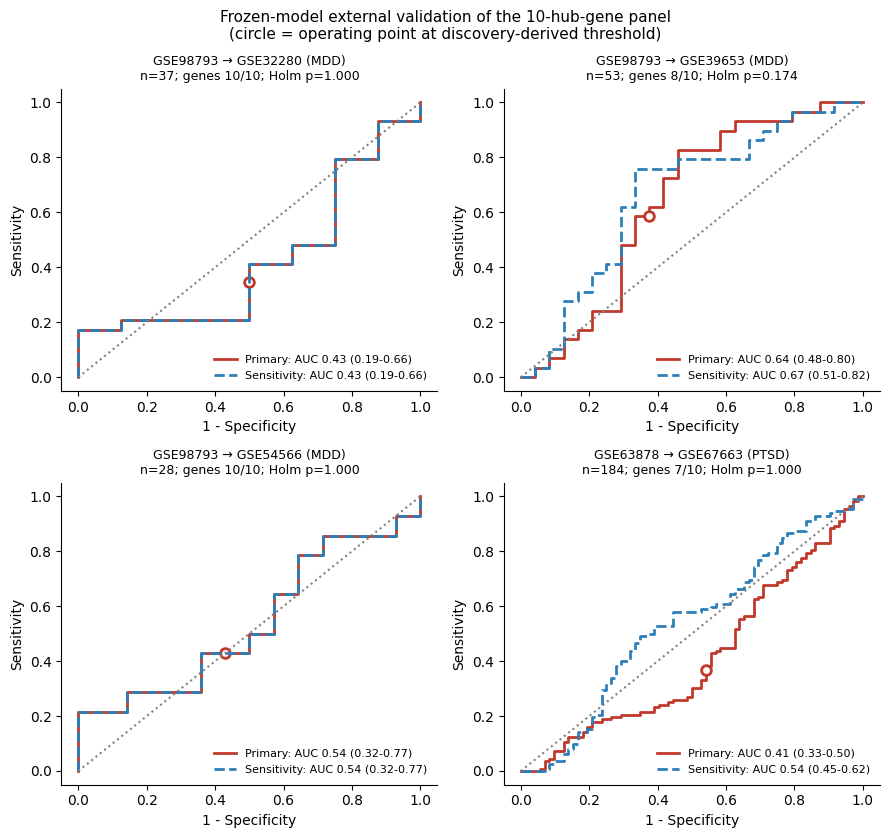

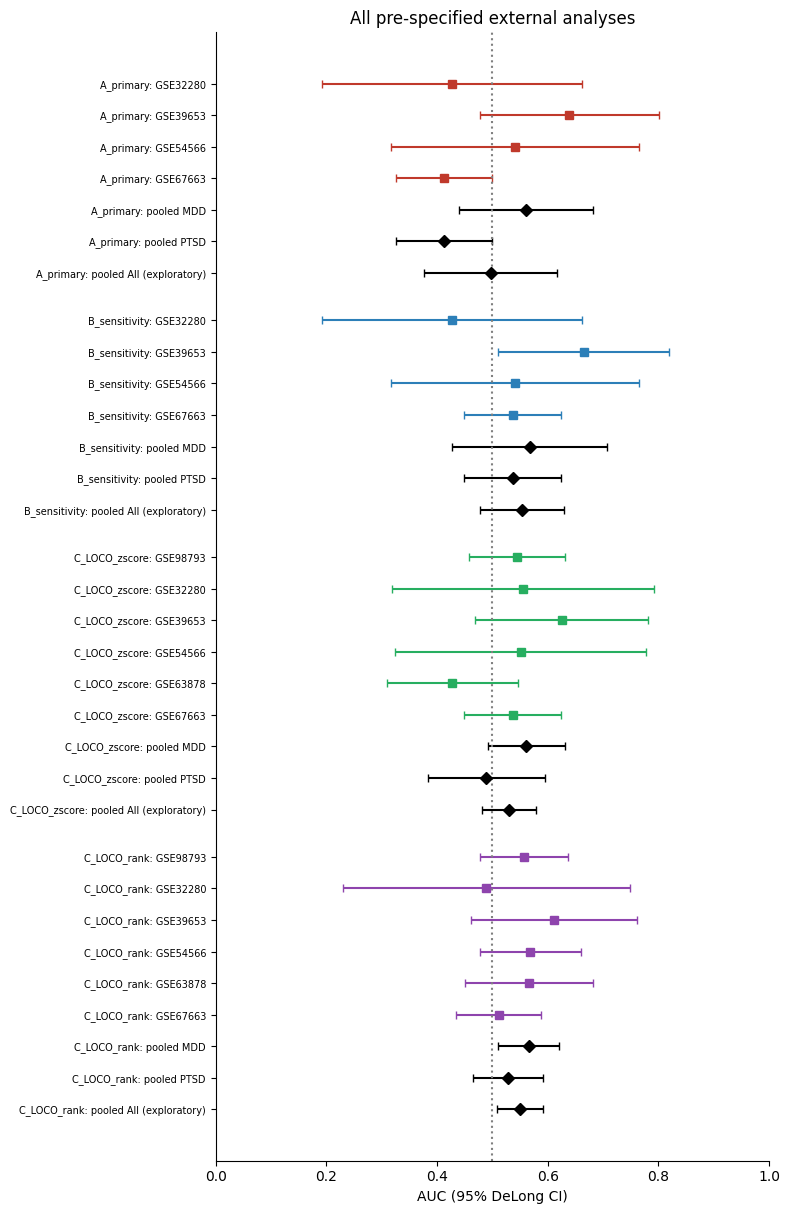


            Analysis Phenotype                      Train     Test   n  genes_used   AUC  CI_low  CI_high  Sensitivity  Specificity  Balanced_accuracy  p_perm  p_perm_Holm
          A_primary       MDD                   GSE98793 GSE32280  37          10 0.427   0.192    0.661        0.345        0.500              0.422   0.727        1.000
          A_primary       MDD                   GSE98793 GSE39653  53           8 0.639   0.478    0.801        0.586        0.625              0.606   0.044        0.174
          A_primary       MDD                   GSE98793 GSE54566  28          10 0.541   0.317    0.765        0.429        0.571              0.500   0.362        1.000
          A_primary      PTSD                   GSE63878 GSE67663 184           7 0.413   0.327    0.499        0.366        0.458              0.412   0.976        1.000
      B_sensitivity       MDD                   GSE98793 GSE32280  37          10 0.427   0.192    0.661        0.345        0.500             

In [ ]:
"""
FINAL VALIDATION PIPELINE  -- Reviewer #2, Concerns #5 and #6
Run ONCE. Report EVERY analysis below, whatever the result.

Pre-specified analyses
  A. PRIMARY   : frozen external validation. ONE L2 logistic-regression model per phenotype,
                 trained on all 10 hub genes in the discovery cohort only (GSE98793 = MDD,
                 GSE63878 = PTSD). Coefficients, intercept and threshold saved before validation.
                 Genes missing in a validation cohort are set to 0 (= cohort mean on z-scale).
  B. SENSITIVITY: as A, but the discovery model is refitted on the genes available in each
                 validation cohort, then frozen (addresses missing genes).
  C. SECONDARY : leave-one-cohort-out (LOCO) within phenotype; model trained on all other cohorts
                 of the same phenotype, applied frozen to the held-out one. Two pre-specified
                 feature representations: per-cohort z-score and within-sample rank.
  D. INTERNAL  : within-cohort nested repeated cross-validation (NOT external validation).

Common rules
  * Model: LogisticRegression(L2, class_weight='balanced'); C = 1.0 for A-C, nested-tuned in D.
  * Scale: log2(x+1) if cohort max > 50. Probes of one gene averaged. Missing -> cohort median.
  * Normalisation: per-cohort gene-wise z-score (no parameters transferred between cohorts).
  * Threshold: Youden index on out-of-fold / out-of-cohort TRAINING predictions only.
  * CI: DeLong 95% (primary), stratified bootstrap (secondary).
  * p: one-sided permutation test; Holm correction within each analysis.
  * Pooling: DerSimonian-Laird random effects, per phenotype (all-cohort pool = exploratory).
  * AUC < 0.5 is reported as is and never flipped. GSE10041 is excluded (not case-control).
"""
import os, re, json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

# =============================================================================== CONFIG
BASE = os.environ.get("BASE", "/content/drive/MyDrive/research/p5-stress_depression/"
                      "p5_stress_depression_journal-20260927T103230Z-1-001/"
                      "p5_stress_depression_journal/Final_validation/")
OUT = os.path.join(BASE, "FINAL_reviewer_round3")
os.makedirs(OUT, exist_ok=True)
FILE = lambda n: os.path.join(BASE, f"{n}_matrix_Transpose_labeled.csv")

DISCOVERY = {"MDD": "GSE98793", "PTSD": "GSE63878"}
VALIDATION = {"GSE32280": "MDD", "GSE39653": "MDD", "GSE54566": "MDD", "GSE67663": "PTSD"}
PHENOTYPE = {**{v: k for k, v in DISCOVERY.items()}, **VALIDATION}

# Fill from GEO before running (goes into Supplementary Table: cohort characteristics)
TISSUE = {n: "UNSPECIFIED" for n in PHENOTYPE}
PLATFORM = {"GSE98793": "GPL570", "GSE63878": "GPL6244",
            **{n: "UNSPECIFIED" for n in VALIDATION}}
CASE_VALUE = 1                    # target == 1 is case; bipolar/SSD already excluded

GENES = ["IGF1R", "STAT2", "PML", "HGF", "HDAC1", "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3"]
SEED = 42
N_PERM = int(os.environ.get("N_PERM", 5000))
N_BOOT = int(os.environ.get("N_BOOT", 2000))
N_CV = int(os.environ.get("N_CV", 10))                       # repeats of 5-fold CV
N_PERM_INTERNAL = int(os.environ.get("N_PERM_INTERNAL", 100))  # each re-runs nested CV
RUN_INTERNAL = os.environ.get("RUN_INTERNAL", "1") == "1"
C_GRID = [0.01, 0.1, 1.0, 10.0]
rng = np.random.RandomState(SEED)


# =============================================================================== DATA
def read_cohort(name):
    df = pd.read_csv(FILE(name))
    y = (df["target"].values == CASE_VALUE).astype(int)
    expr = df.drop(columns=["target"]).apply(pd.to_numeric, errors="coerce")
    expr = expr.loc[:, expr.notna().any()]
    raw_min, raw_max = float(np.nanmin(expr.values)), float(np.nanmax(expr.values))
    logged = raw_max > 50
    if logged:
        expr = np.log2(expr.clip(lower=0) + 1)
    feats, nprobe = {}, {}
    for g in GENES:
        pat = re.compile(rf"^{re.escape(g)}(\.\d+)?$", re.IGNORECASE)
        cols = [c for c in expr.columns if pat.match(str(c).strip())]
        if cols:
            v = expr[cols].mean(axis=1)
            if v.notna().any():
                feats[g], nprobe[g] = v, len(cols)
    X = pd.DataFrame(feats)
    n_missing_vals = int(X.isna().sum().sum())
    X = X.fillna(X.median())
    info = dict(Cohort=name, Phenotype=PHENOTYPE[name],
                Role="Discovery" if name in DISCOVERY.values() else "Validation",
                Platform=PLATFORM[name], Tissue=TISSUE[name], n=len(y), n_case=int(y.sum()),
                n_ctrl=int((1 - y).sum()), raw_min=round(raw_min, 3), raw_max=round(raw_max, 3),
                log2_applied=logged, genes_available=len(feats),
                genes_missing=", ".join(g for g in GENES if g not in feats) or "none",
                imputed_values=n_missing_vals, **{f"probes_{g}": nprobe.get(g, 0) for g in GENES})
    return X, y, info


DATA = {n: read_cohort(n) for n in PHENOTYPE}
pd.DataFrame([d[2] for d in DATA.values()]).to_csv(f"{OUT}/S_cohort_characteristics.csv", index=False)
print("Cohorts:")
for n, (_, _, i) in DATA.items():
    print(f"  {n} [{i['Role']}, {i['Phenotype']}] case={i['n_case']} ctrl={i['n_ctrl']} "
          f"genes={i['genes_available']}/10 log2={i['log2_applied']}")


def zscore(X):
    return (X - X.mean()) / X.std(ddof=0).replace(0, 1)


def rank_feat(X):
    return (X.rank(axis=1) - 1) / max(X.shape[1] - 1, 1)


def features(name, genes, kind="zscore", fill_missing=False):
    X = DATA[name][0]
    if fill_missing:                                   # primary: keep all 10 genes
        Z = zscore(X).reindex(columns=genes).fillna(0.0)
        return Z
    X = X[genes]
    return zscore(X) if kind == "zscore" else rank_feat(X)


# =============================================================================== STATS
def lr(C=1.0):
    return LogisticRegression(C=C, class_weight="balanced", max_iter=5000)


def _midrank(x):
    J = np.argsort(x, kind="mergesort"); Z = x[J]; N = len(x); T = np.zeros(N); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1; i = j
    T2 = np.empty(N); T2[J] = T
    return T2


def delong(y, p):
    pos, neg = p[y == 1], p[y == 0]; m, n = len(pos), len(neg)
    tx, ty, tz = _midrank(pos), _midrank(neg), _midrank(np.concatenate([pos, neg]))
    auc = (tz[:m].sum() / m - (m + 1) / 2) / n
    var = np.var((tz[:m] - tx) / n, ddof=1) / m + np.var(1 - (tz[m:] - ty) / m, ddof=1) / n
    return auc, var


def holm(p):
    p = np.asarray(p, float); o = np.argsort(p); adj = np.empty_like(p); run = 0.0
    for k, i in enumerate(o):
        run = max(run, (len(p) - k) * p[i]); adj[i] = min(1.0, run)
    return adj


def youden(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    return float(thr[np.argmax(tpr - fpr)])


def oof_cv(X, y, C=1.0):
    acc = np.zeros(len(y))
    for r in range(N_CV):
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED + r).split(X, y):
            acc[te] += lr(C).fit(X.iloc[tr], y[tr]).predict_proba(X.iloc[te])[:, 1]
    return acc / N_CV


def evaluate(y, prob, thr, permute=True):
    auc, var = delong(y, prob); se = np.sqrt(var)
    i0, i1 = np.where(y == 0)[0], np.where(y == 1)[0]
    boots = [roc_auc_score(y[i], prob[i]) for i in
             (np.concatenate([rng.choice(i0, len(i0)), rng.choice(i1, len(i1))]) for _ in range(N_BOOT))]
    out = dict(AUC=auc, SE=se, CI_low=max(0, auc - 1.96 * se), CI_high=min(1, auc + 1.96 * se),
               Boot_CI_low=np.percentile(boots, 2.5), Boot_CI_high=np.percentile(boots, 97.5),
               p_DeLong_vs_0_5=2 * (1 - stats.norm.cdf(abs((auc - 0.5) / se))))
    if permute:
        perm = np.array([roc_auc_score(rng.permutation(y), prob) for _ in range(N_PERM)])
        out["p_perm"] = (np.sum(perm >= auc) + 1) / (N_PERM + 1)
    if thr is not None:
        pred = prob >= thr
        tp = int((pred & (y == 1)).sum()); fn = int((~pred & (y == 1)).sum())
        tn = int((~pred & (y == 0)).sum()); fp = int((pred & (y == 0)).sum())
        sens, spec = tp / (tp + fn), tn / (tn + fp)
        out.update(Threshold=thr, TP=tp, FN=fn, TN=tn, FP=fp, Sensitivity=sens, Specificity=spec,
                   Accuracy=(tp + tn) / len(y), Balanced_accuracy=(sens + spec) / 2)
    return out


def random_effects(a, se):
    v = se ** 2; w = 1 / v; k = len(a)
    afe = (w * a).sum() / w.sum(); Q = (w * (a - afe) ** 2).sum()
    tau2 = max(0, (Q - (k - 1)) / (w.sum() - (w ** 2).sum() / w.sum())) if k > 1 else 0.0
    wr = 1 / (v + tau2); are = (wr * a).sum() / wr.sum(); s = np.sqrt(1 / wr.sum())
    return dict(k=k, pooled_AUC=are, CI_low=are - 1.96 * s, CI_high=are + 1.96 * s, tau2=tau2,
                I2_percent=max(0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0.0,
                p_vs_0_5=2 * (1 - stats.norm.cdf(abs((are - 0.5) / s))))


results, coef_rows, rocs = [], [], {}

# =============================================================================== A. PRIMARY
print("\n=== A. PRIMARY: single frozen 10-gene model per phenotype ===")
frozen = {}
for pheno, disc in DISCOVERY.items():
    Zd, yd = features(disc, GENES, fill_missing=True), DATA[disc][1]
    p_oof = oof_cv(Zd, yd)
    thr = youden(yd, p_oof)
    m = lr().fit(Zd, yd)
    frozen[pheno] = (m, thr)
    a_oof, v_oof = delong(yd, p_oof)
    coef_rows.append(dict(Analysis="A_primary", Phenotype=pheno, Discovery=disc, Validation="all",
                          Intercept=m.intercept_[0], Threshold=thr, Discovery_OOF_AUC=a_oof,
                          OOF_CI_low=a_oof - 1.96 * np.sqrt(v_oof),
                          OOF_CI_high=a_oof + 1.96 * np.sqrt(v_oof),
                          **dict(zip(GENES, m.coef_[0]))))
    print(f"  FROZEN {pheno} ({disc}): OOF AUC {a_oof:.3f}, threshold {thr:.3f}")
pd.DataFrame(coef_rows).round(4).to_csv(f"{OUT}/S_frozen_coefficients_primary.csv", index=False)

for val, pheno in VALIDATION.items():
    m, thr = frozen[pheno]
    Zv, yv = features(val, GENES, fill_missing=True), DATA[val][1]
    prob = m.predict_proba(Zv[GENES])[:, 1]
    r = dict(Analysis="A_primary", Phenotype=pheno, Train=DISCOVERY[pheno], Test=val,
             n=len(yv), genes_used=DATA[val][2]["genes_available"], **evaluate(yv, prob, thr))
    results.append(r)
    fpr, tpr, _ = roc_curve(yv, prob)
    rocs[("A", val)] = (fpr, tpr, r)
    print(f"  {DISCOVERY[pheno]} -> {val}: AUC {r['AUC']:.3f} [{r['CI_low']:.3f}, {r['CI_high']:.3f}]")

# =============================================================================== B. SENSITIVITY
print("\n=== B. SENSITIVITY: discovery model refitted on available genes, then frozen ===")
for val, pheno in VALIDATION.items():
    disc = DISCOVERY[pheno]
    common = [g for g in GENES if g in DATA[disc][0].columns and g in DATA[val][0].columns]
    Zd, yd = features(disc, common), DATA[disc][1]
    Zv, yv = features(val, common), DATA[val][1]
    thr = youden(yd, oof_cv(Zd, yd))
    m = lr().fit(Zd, yd)
    coef_rows.append(dict(Analysis="B_sensitivity", Phenotype=pheno, Discovery=disc, Validation=val,
                          Intercept=m.intercept_[0], Threshold=thr, **dict(zip(common, m.coef_[0]))))
    prob = m.predict_proba(Zv)[:, 1]
    r = dict(Analysis="B_sensitivity", Phenotype=pheno, Train=disc, Test=val, n=len(yv),
             genes_used=len(common), **evaluate(yv, prob, thr))
    results.append(r)
    fpr, tpr, _ = roc_curve(yv, prob)
    rocs[("B", val)] = (fpr, tpr, r)
    print(f"  {disc} -> {val} ({len(common)} genes): AUC {r['AUC']:.3f} [{r['CI_low']:.3f}, {r['CI_high']:.3f}]")
pd.DataFrame(coef_rows).round(4).to_csv(f"{OUT}/S_frozen_coefficients_all.csv", index=False)

# =============================================================================== C. LOCO
print("\n=== C. SECONDARY: leave-one-cohort-out within phenotype ===")
for kind in ["zscore", "rank"]:
    for pheno in DISCOVERY:
        cohorts = [c for c, ph in PHENOTYPE.items() if ph == pheno]
        for test in cohorts:
            train = [c for c in cohorts if c != test]
            genes = [g for g in GENES if all(g in DATA[c][0].columns for c in cohorts)]
            Xtr = pd.concat([features(c, genes, kind) for c in train], ignore_index=True)
            ytr = np.concatenate([DATA[c][1] for c in train])
            grp = np.concatenate([[c] * len(DATA[c][1]) for c in train])
            if len(train) >= 2:
                p_in = np.zeros(len(ytr))
                for g in train:
                    te = grp == g
                    p_in[te] = lr().fit(Xtr[~te], ytr[~te]).predict_proba(Xtr[te])[:, 1]
            else:
                p_in = oof_cv(Xtr, ytr)
            thr = youden(ytr, p_in)
            m = lr().fit(Xtr, ytr)
            Xte, yte = features(test, genes, kind), DATA[test][1]
            prob = m.predict_proba(Xte)[:, 1]
            r = dict(Analysis=f"C_LOCO_{kind}", Phenotype=pheno, Train="+".join(train), Test=test,
                     n=len(yte), genes_used=len(genes), **evaluate(yte, prob, thr))
            results.append(r)
            print(f"  [{kind}] {pheno} test {test} ({len(genes)} genes): AUC {r['AUC']:.3f} "
                  f"[{r['CI_low']:.3f}, {r['CI_high']:.3f}]")

# =============================================================================== D. INTERNAL
def nested_oof(X, y, seed):
    acc = np.zeros(len(y))
    for r in range(N_CV):
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed + r).split(X, y):
            inner = StratifiedKFold(5, shuffle=True, random_state=seed + 1000 + r)
            best_C, best = 1.0, -1
            for C in C_GRID:
                s = [roc_auc_score(y[tr][b], make_pipeline(SimpleImputer(strategy="median"),
                     StandardScaler(), lr(C)).fit(X[tr][a], y[tr][a]).predict_proba(X[tr][b])[:, 1])
                     for a, b in inner.split(X[tr], y[tr])]
                if np.mean(s) > best:
                    best, best_C = np.mean(s), C
            pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), lr(best_C))
            acc[te] += pipe.fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
    return acc / N_CV


if RUN_INTERNAL:
    print("\n=== D. INTERNAL: within-cohort nested CV (not external validation) ===")
    for name in PHENOTYPE:
        X, y = DATA[name][0].values, DATA[name][1]
        p = nested_oof(X, y, SEED)
        r = evaluate(y, p, None, permute=False)
        null = [roc_auc_score(yp, nested_oof(X, yp, SEED + 7))
                for yp in (rng.permutation(y) for _ in range(N_PERM_INTERNAL))]
        r["p_perm"] = (np.sum(np.array(null) >= r["AUC"]) + 1) / (N_PERM_INTERNAL + 1)
        results.append(dict(Analysis="D_internal_nestedCV", Phenotype=PHENOTYPE[name], Train=name,
                            Test=name, n=len(y), genes_used=X.shape[1], **r))
        print(f"  {name}: internal AUC {r['AUC']:.3f} [{r['CI_low']:.3f}, {r['CI_high']:.3f}]")

# =============================================================================== SAVE + META
res = pd.DataFrame(results)
for a in res.Analysis.unique():
    m = res.Analysis == a
    res.loc[m, "p_perm_Holm"] = holm(res.loc[m, "p_perm"].values)
res.round(4).to_csv(f"{OUT}/ALL_results.csv", index=False)

meta = []
for a in [x for x in res.Analysis.unique() if not x.startswith("D_")]:
    d = res[res.Analysis == a]
    for ph, dd in d.groupby("Phenotype"):
        meta.append(dict(Analysis=a, Pool=ph, **random_effects(dd.AUC.values, dd.SE.values)))
    meta.append(dict(Analysis=a, Pool="All (exploratory)", **random_effects(d.AUC.values, d.SE.values)))
meta = pd.DataFrame(meta)
meta.round(4).to_csv(f"{OUT}/ALL_meta_analysis.csv", index=False)

# =============================================================================== FIGURES
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
vals = list(VALIDATION)
fig, axes = plt.subplots(2, 2, figsize=(9, 8.5))
for ax, val in zip(axes.ravel(), vals):
    for key, ls, col, lab in [("A", "-", "#c0392b", "Primary"), ("B", "--", "#2c7fb8", "Sensitivity")]:
        fpr, tpr, r = rocs[(key, val)]
        ax.plot(fpr, tpr, ls, color=col, lw=2,
                label=f"{lab}: AUC {r['AUC']:.2f} ({r['CI_low']:.2f}-{r['CI_high']:.2f})")
        if key == "A":
            ax.plot(1 - r["Specificity"], r["Sensitivity"], "o", color=col, ms=7, mfc="white", mew=2)
    ra = rocs[("A", val)][2]
    ax.plot([0, 1], [0, 1], ":", color="grey")
    ax.set_title(f"{DISCOVERY[VALIDATION[val]]} → {val} ({VALIDATION[val]})\n"
                 f"n={ra['n']}; genes {ra['genes_used']}/10; Holm p="
                 f"{res[(res.Analysis=='A_primary') & (res.Test==val)].p_perm_Holm.iloc[0]:.3f}", fontsize=9)
    ax.set_xlabel("1 - Specificity"); ax.set_ylabel("Sensitivity")
    ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.suptitle("Frozen-model external validation of the 10-hub-gene panel\n"
             "(circle = operating point at discovery-derived threshold)", fontsize=11)
fig.tight_layout()
fig.savefig(f"{OUT}/Fig7_ROC_frozen.png", dpi=300); fig.savefig(f"{OUT}/Fig7_ROC_frozen.pdf")

ext = res[~res.Analysis.str.startswith("D_")]
labels, ys, y0 = [], [], 0
fig2, ax = plt.subplots(figsize=(8, 0.32 * (len(ext) + len(meta)) + 2))
colors = {"A_primary": "#c0392b", "B_sensitivity": "#2c7fb8",
          "C_LOCO_zscore": "#27ae60", "C_LOCO_rank": "#8e44ad"}
for a in colors:
    for _, r in ext[ext.Analysis == a].iterrows():
        ax.errorbar(r.AUC, -y0, xerr=[[r.AUC - r.CI_low], [r.CI_high - r.AUC]], fmt="s",
                    color=colors[a], capsize=3)
        labels.append(f"{a}: {r.Test}"); ys.append(-y0); y0 += 1
    for _, m in meta[meta.Analysis == a].iterrows():
        ax.errorbar(m.pooled_AUC, -y0, xerr=[[m.pooled_AUC - m.CI_low], [m.CI_high - m.pooled_AUC]],
                    fmt="D", color="black", capsize=3)
        labels.append(f"{a}: pooled {m.Pool}"); ys.append(-y0); y0 += 1
    y0 += 0.5
ax.axvline(0.5, ls=":", color="grey"); ax.set_xlim(0, 1)
ax.set_yticks(ys); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("AUC (95% DeLong CI)")
ax.set_title("All pre-specified external analyses")
fig2.tight_layout()
fig2.savefig(f"{OUT}/FigS_forest_all.png", dpi=300); fig2.savefig(f"{OUT}/FigS_forest_all.pdf")

if os.environ.get("SHOW", "1") == "1":
    plt.show()

# =============================================================================== SUMMARY
cols = ["Analysis", "Phenotype", "Train", "Test", "n", "genes_used", "AUC", "CI_low", "CI_high",
        "Sensitivity", "Specificity", "Balanced_accuracy", "p_perm", "p_perm_Holm"]
print("\n", res[[c for c in cols if c in res]].round(3).to_string(index=False))
print("\n", meta.round(3).to_string(index=False))
json.dump(dict(N_PERM=N_PERM, N_BOOT=N_BOOT, N_CV=N_CV, N_PERM_INTERNAL=N_PERM_INTERNAL,
               SEED=SEED, C_GRID=C_GRID, genes=GENES, discovery=DISCOVERY, validation=VALIDATION),
          open(f"{OUT}/run_settings.json", "w"), indent=2)
print(f"\nSaved to {OUT}")

In [ ]:
"""Build Supplementary Table S10 (frozen coefficients) from the SAME run as Table 5.
Run in Colab after frozen_external_validation_v2.py. Reads reviewer_final_v2/frozen_coefficients.csv."""
import os
import pandas as pd

BASE = ("/content/drive/MyDrive/research/p5-stress_depression/"
        "p5_stress_depression_journal-20260927T103230Z-1-001/"
        "p5_stress_depression_journal/Final_validation/reviewer_final_v2/")
GENES = ["IGF1R", "STAT2", "PML", "HGF", "HDAC1", "JAK2", "JAK1", "MDM2", "ERBB2", "STAT3"]

c = pd.read_csv(os.path.join(BASE, "frozen_coefficients.csv"))
c = c.rename(columns={"Train": "Discovery", "Test": "Validation",
                      "Threshold_Youden_train": "Threshold_Youden_discovery"})
for g in GENES:
    if g not in c.columns:
        c[g] = None
out = c[["Panel", "Discovery", "Validation", "Intercept", "Threshold_Youden_discovery"] + [g for g in GENES]]
out = out.round(4).fillna("not available")

# sanity check: MDD 10-hub threshold of this run must match Table 5 (0.551)
mdd = out[(out.Panel == "10 hub genes") & (out.Validation == "GSE32280")]["Threshold_Youden_discovery"]
print("MDD 10-hub threshold in this file:", mdd.values, "(Table 5 run = 0.551)")

out.to_csv(os.path.join(BASE, "S10_frozen_model_coefficients.csv"), index=False, encoding="utf-8-sig")
print(out.to_string(index=False))
print("\nSaved S10_frozen_model_coefficients.csv")

MDD 10-hub threshold in this file: [0.5507] (Table 5 run = 0.551)
       Panel Discovery Validation  Intercept  Threshold_Youden_discovery         IGF1R         STAT2    PML           HGF         HDAC1          JAK2          JAK1          MDM2         ERBB2         STAT3
10 hub genes  GSE98793   GSE32280     0.1719                      0.5507        0.8164         0.407 0.1991        0.2309       -0.3929        0.0375       -0.6497       -0.0421        0.0866       -0.3164
10 hub genes  GSE98793   GSE39653     0.0913                      0.5120 not available not available 0.2866        0.2699        -0.727       -0.0542       -0.6841        0.1302         0.048        0.0343
10 hub genes  GSE98793   GSE54566     0.1719                      0.5507        0.8164         0.407 0.1991        0.2309       -0.3929        0.0375       -0.6497       -0.0421        0.0866       -0.3164
10 hub genes  GSE63878   GSE67663     0.0219                      0.4723 not available       -0.0935 1.1533 no